In [32]:
import numpy as np
import pandas as pd 
import seaborn as sns
import os
import csv
import matplotlib.pyplot as plt

# project specific
import gseapy as gp
from gseapy import barplot, dotplot

## Comparison of Human and Mouse at Individual Gene Level

We first read in the `log2FoldChange` of differentially expressed genes between human and mouse.

In [145]:
genes_dge_human_06 = pd.read_csv('DeSeqStats_results/GSE130970_6-vs-0_results.csv')
genes_dge_mouse_12 = pd.read_csv('DeSeqStats_results/GSE167216_ccl4_12-vs-control_12_results.csv')

The following code is used to build a scatterplot comparing the `log2FoldChange` across the transcriptome between human and mouse DeSeq data. 

In [172]:
def plot_gene_scatter(genes_human, genes_mouse, title="Differential Gene Expression Comparison"):
    """
    Create scatter plot comparing human vs mouse log2 fold changes.
    """

    x = genes_human
    y = genes_mouse

    plt.figure(figsize=(7,7))
    plt.scatter(x, y, s=7, alpha=0.1)
    plt.gca().set_aspect('equal', adjustable='box')
    
    # Axis labels
    plt.xlabel("Human log2FoldChange")
    plt.ylabel("Mouse log2FoldChange")
    plt.title(title)

    # Reference lines
    plt.axhline(0)
    plt.axvline(0)

    # Limits
    plt.ylim(-5, 10)
    plt.xlim(-5, 10)

    # Diagonal (perfect agreement)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.grid(True)
    plt.show()

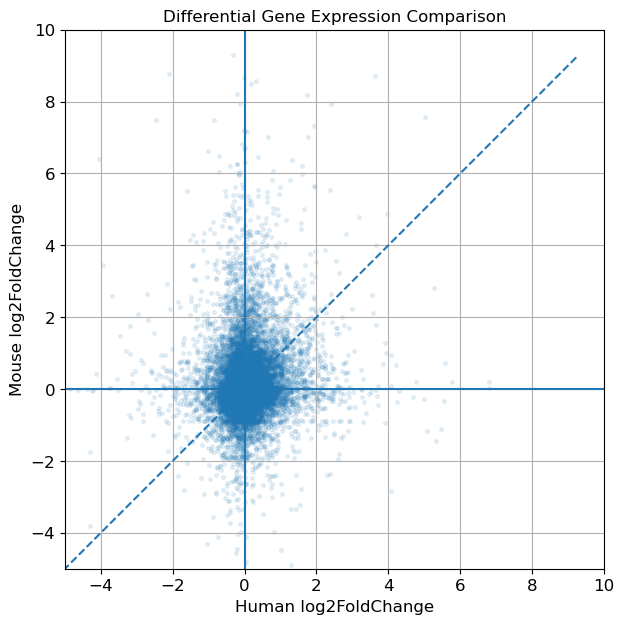

In [173]:
plot_gene_scatter(genes_dge_human_06['log2FoldChange'], genes_dge_mouse_12['log2FoldChange'])

This isn't very useful. Instead, we apply a filter to the genes displayed, only allowing genes that have a `log2FoldChange` with a magnitude **greater than 1**; this reflects that the gene experienced a 2-fold change in expression.

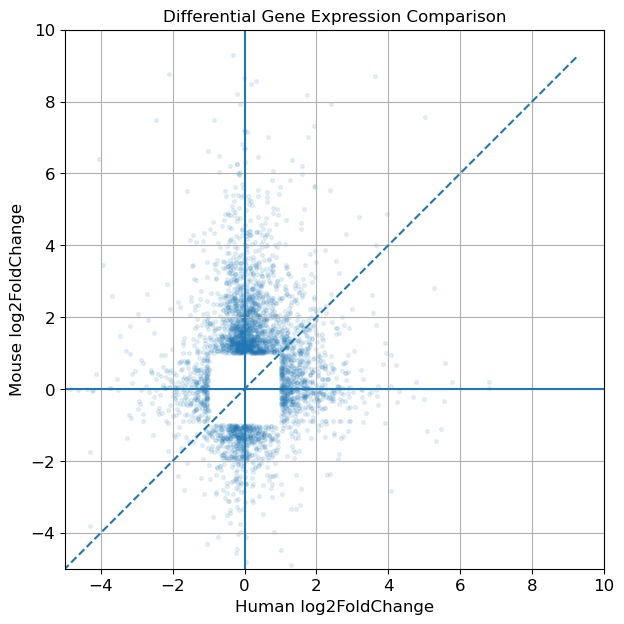

In [174]:
mask = (
    (genes_dge_human_06["log2FoldChange"].abs() > 1) |
    (genes_dge_mouse_12["log2FoldChange"].abs() > 1)
)

human_filtered = genes_dge_human_06[mask]
mouse_filtered = genes_dge_mouse_12[mask]

plot_gene_scatter(human_filtered['log2FoldChange'], mouse_filtered['log2FoldChange'])

Onto more useful metrics, we now apply a similar mask to only include datapoints where the `p-value` is statistically significant (<0.05).

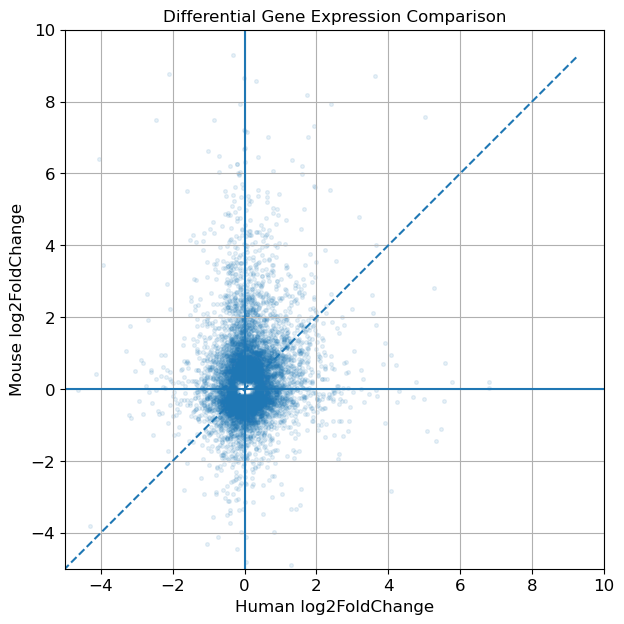

In [175]:
mask = (
    (genes_dge_human_06["pvalue"] < 0.05) |
    (genes_dge_mouse_12["pvalue"] < 0.05)
)

human_filtered = genes_dge_human_06[mask]
mouse_filtered = genes_dge_mouse_12[mask]


plot_gene_scatter(human_filtered['log2FoldChange'], mouse_filtered['log2FoldChange'])

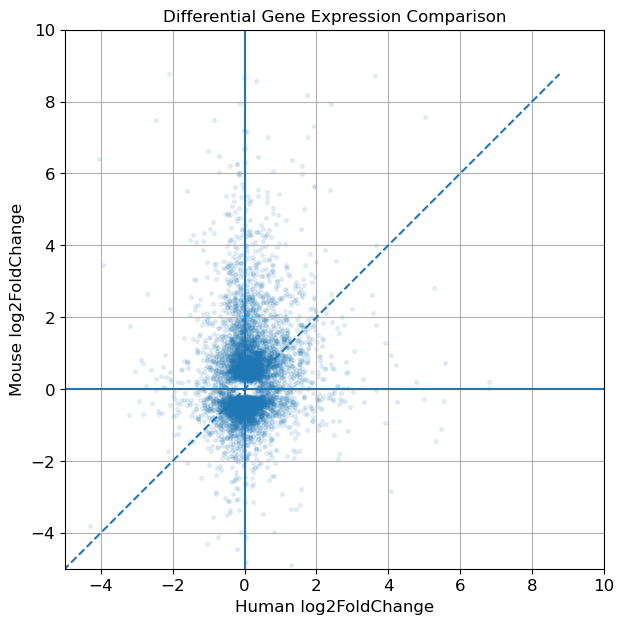

In [176]:
mask = (
    (genes_dge_human_06["padj"] < 0.05) |
    (genes_dge_mouse_12["padj"] < 0.05)
)

human_filtered = genes_dge_human_06[mask]
mouse_filtered = genes_dge_mouse_12[mask]


plot_gene_scatter(human_filtered['log2FoldChange'], mouse_filtered['log2FoldChange'])

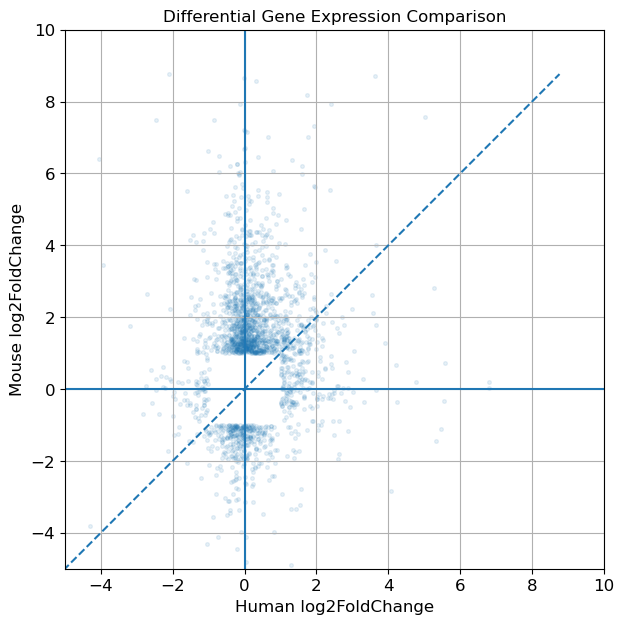

In [177]:
mask = (
    (genes_dge_human_06["padj"] < 0.05) & (genes_dge_human_06["log2FoldChange"].abs() > 1) |
    (genes_dge_mouse_12["padj"] < 0.05) & (genes_dge_mouse_12["log2FoldChange"].abs() > 1) 
)

human_filtered = genes_dge_human_06[mask]
mouse_filtered = genes_dge_mouse_12[mask]


plot_gene_scatter(human_filtered['log2FoldChange'], mouse_filtered['log2FoldChange'])

## Gene set enrichment analysis

Now that we have the DeSeqStats, we can perform **gene set enrichment analysis**. This will allow us to find which genes significantly change between control states and disease states. 

First, loading in the results from the DeSeqStats runs, which were exported as .csv files. From this import, we want to drop genes that report a NaN result within the `log2FoldChange` column, as downstream GSEA cannot work with NaN values.

In [33]:
def load_deseq_results(filepath):
    df = pd.read_csv(filepath, index_col=0)
    df = df.dropna(subset=["log2FoldChange"])
    
    return df

In [34]:
gse130970_06_dss = load_deseq_results("DeSeqStats_results/GSE130970_6-vs-0_results.csv")
gse167216_2_dss = load_deseq_results("DeSeqStats_results/GSE167216_ccl4_2-vs-control_2_results.csv")
gse167216_12_dss = load_deseq_results("DeSeqStats_results/GSE167216_ccl4_12-vs-control_12_results.csv")
gse130970_06_dss

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
a1bg,9904.557248,-0.163190,0.202012,-0.807820,0.419194,0.661685
a1cf,17830.995243,-0.472009,0.226232,-2.086388,0.036943,0.181869
a2m,54959.116441,-0.423890,0.337767,-1.254977,0.209487,0.461717
a3galt2,0.170707,-1.720353,3.445475,-0.499308,0.617562,NaN
a4galt,15.706376,0.266344,0.480858,0.553893,0.579652,0.778998
...,...,...,...,...,...,...
zyg11a,206.445998,-0.844324,0.224551,-3.760053,0.000170,0.006341
zyg11b,2866.622774,0.006426,0.209608,0.030656,0.975544,0.989518
zyx,376.293377,1.334845,0.319774,4.174343,0.000030,0.001721


The next step of GSEA involves **ranking** the genes, which can be done with any number of metrics, but we will use the `log2FoldChange` value as our ranking, which was already discovered in our `deseq2` method.

In [35]:
def make_ranked_list(df):
    
    scores = df["log2FoldChange"]
    scores = scores[~scores.index.duplicated(keep="first")]
    ranked = scores.sort_values(ascending=False)
    
    return ranked

In [36]:
gse130970_06_dss_ranked = make_ranked_list(gse130970_06_dss)
gse167216_2_dss_ranked = make_ranked_list(gse167216_2_dss)
gse167216_12_dss_ranked = make_ranked_list(gse167216_12_dss)
gse167216_12_dss_ranked

gene
sult2a1     9.289440
krt5        8.764629
elfn2       8.705634
tekt5       8.666202
krt13       8.616383
             ...    
pitx3      -6.889291
irx1       -6.914108
reg3a      -7.442241
hhip       -7.578733
moxd1     -12.419144
Name: log2FoldChange, Length: 14697, dtype: float64

In [37]:
def run_gsea(ranked_series, gene_sets, outdir=None):
    """
    Parameters
    ranked_series (list) - list produced by make_ranked_list
    gene_sets (string) - title of a valid gene set within Enrichr database - ex. "KEGG_2021_Human" (human gene set)
    outdir (string) - saves gsea results to specified file directory
    """
    pre_res = gp.prerank(
        rnk=ranked_series,
        gene_sets=gene_sets,
        processes=4,
        permutation_num=1000,
        seed=512,
        outdir=outdir,
        verbose=True
    )
    
    res = pre_res.res2d
    
    return res

In [180]:
gene_sets = "KEGG_2021_Human"

gse130970_06_gsea = run_gsea(gse130970_06_dss_ranked, gene_sets, outdir="gse130970_06_gsea/")
gse167216_2_gsea = run_gsea(gse167216_2_dss_ranked, gene_sets, outdir="gse167216_2_gsea/")
gse167216_12_gsea = run_gsea(gse167216_12_dss_ranked, gene_sets, outdir="gse167216_12_gsea/")

/tmp/ipykernel_3857847/2687924404.py:8: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(
2026-04-21 22:18:28,303 [WARNING] Duplicated values found in preranked stats: 1.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-21 22:18:28,304 [INFO] Parsing data files for GSEA.............................
2026-04-21 22:18:28,322 [INFO] Enrichr library gene sets already downloaded in: /home/yaogilbe/.cache/gseapy, use local file
2026-04-21 22:18:28,339 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-21 22:18:28,340 [INFO] 0303 gene_sets used for further statistical testing.....
2026-04-21 22:18:28,340 [INFO] Start to run GSEA...Might take a while..................
2026-04-21 22:18:28,342 [INFO] Genes are converted to uppercase.
2026-04-21 22:18:45,062 [INFO] Congratulations. GSEApy runs successfully................

/tmp/ipykernel_3857847/2687924404.py:8: DeprecationWarnin

## Data visualization

In [187]:
def t20_barplot(df, column, gene_set, cutoff, title):
    ax = barplot(df,
                 column=column,
                 group=gene_sets, # set group, so you could do a multi-sample/library comparsion
                 cutoff = cutoff,
                 top_term = 20,
                 figsize=(7,7),
                 color='darkblue')
    plt.title(title)
    return ax

<Axes: title={'center': 'gse130970-human-gsea'}, xlabel='$- \\log_{10}$ (FDR q-val)'>

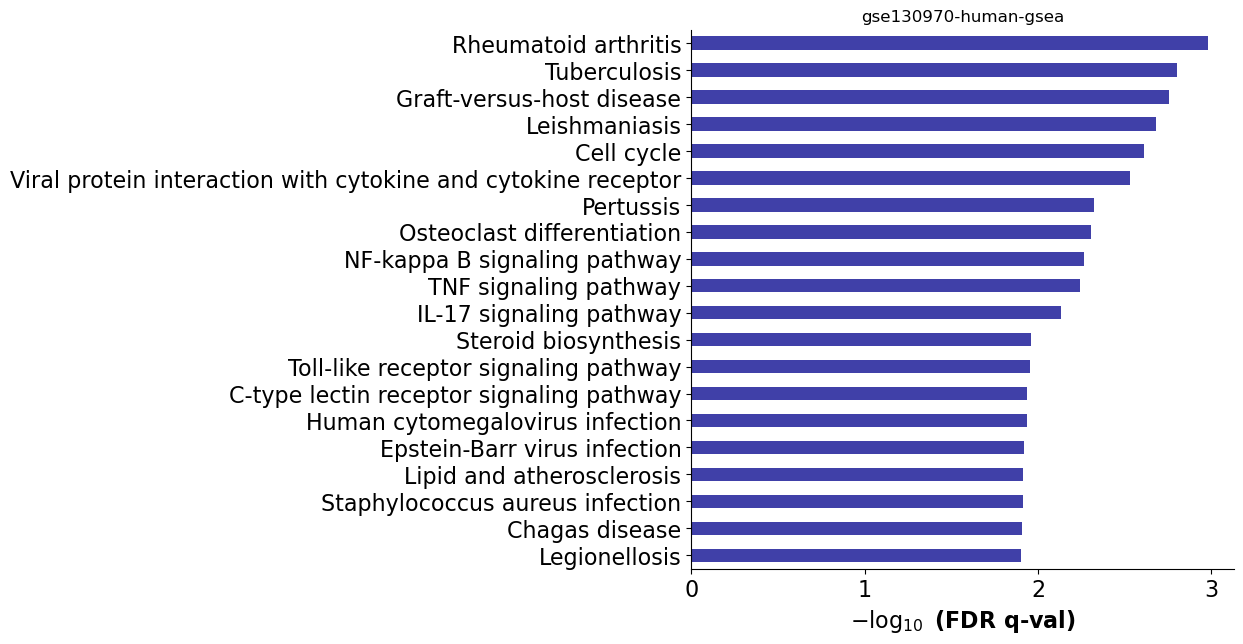

In [191]:
t20_barplot(gse130970_06_gsea, "FDR q-val", gene_sets, 0.1, "gse130970-human-gsea")

In [192]:
# t20_barplot(gse167216_2_gsea, "FDR q-val", gene_sets, 1, "gse167216-mouse-2-gsea")

<Axes: title={'center': 'gse167216-mouse-12-gsea'}, xlabel='$- \\log_{10}$ (FDR q-val)'>

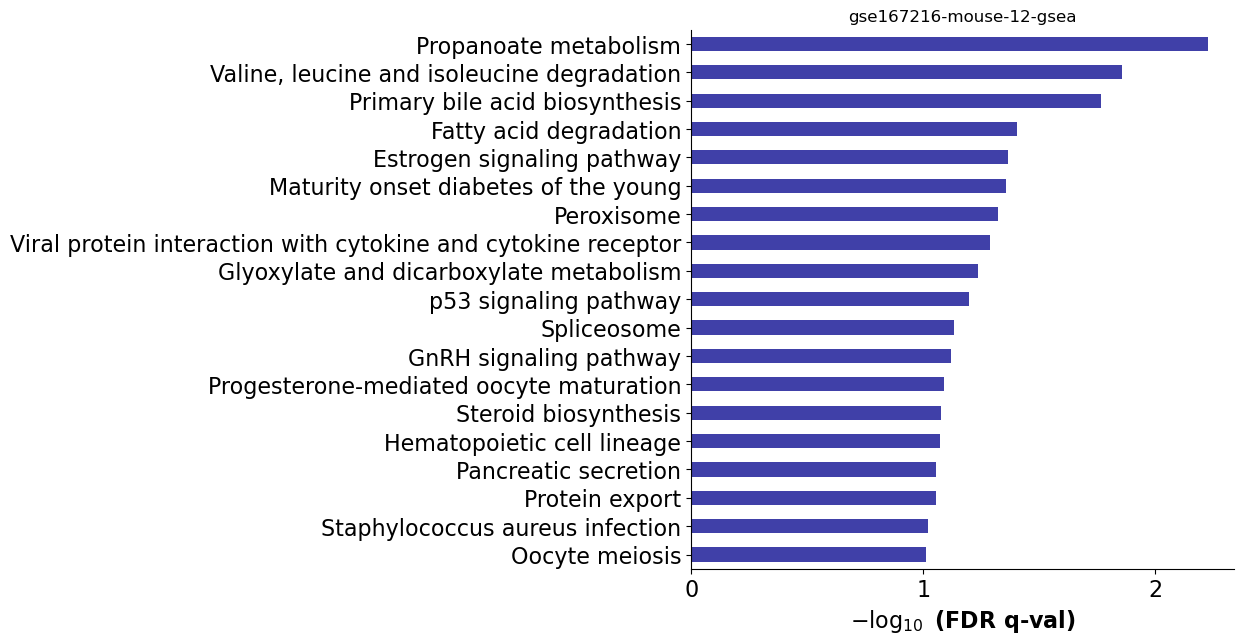

In [193]:
t20_barplot(gse167216_12_gsea, "FDR q-val", gene_sets, 0.1, "gse167216-mouse-12-gsea")

Now, we can pass the GSEA files into a similar scatterplot as before, and compare gene set differences.

In [219]:
def plot_gs_scatter(gs_human, gs_mouse, title="Gene Set Expression Comparison"):
    """
    Create scatter plot comparing human vs mouse log2 fold changes.
    """

    common_terms = set(gs_human["Term"]).intersection(set(gs_mouse["Term"]))

    gs_human = gs_human[gs_human["Term"].isin(common_terms)].copy()
    gs_mouse = gs_mouse[gs_mouse["Term"].isin(common_terms)].copy()
    
    x = gs_human["NES"]
    y = gs_mouse["NES"]

    plt.figure(figsize=(7,7))
    plt.scatter(x, y, s=10, alpha=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    
    # Axis labels
    plt.xlabel("Human NES")
    plt.ylabel("Mouse NES")
    plt.title(title)

    # Reference lines
    plt.axhline(0)
    plt.axvline(0)

    plt.grid(True)
    plt.show()

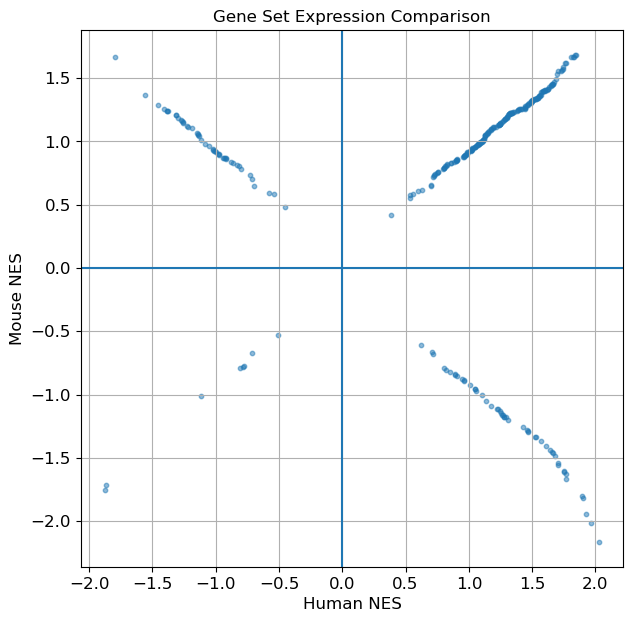

In [220]:
plot_gs_scatter(gse130970_06_gsea, gse167216_12_gsea)

In [197]:
gse130970_06_gsea

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Rheumatoid arthritis,0.650322,2.024893,0.0,0.00105,0.001,32/70,14.71%,ccl20;mmp3;il1a;il1b;cxcl1;ccl2;tnf;jun;ccl3;f...
1,prerank,Tuberculosis,0.578665,1.96462,0.0,0.001575,0.003,64/140,21.29%,calml3;il1a;il1b;tnf;cyp27b1;nos2;ppp3r2;bax;i...
2,prerank,Graft-versus-host disease,0.810385,1.941633,0.0,0.00175,0.005,9/16,7.98%,il1a;il1b;tnf;kir3dl2;kir3dl1;il2;ifng;cd80;cd86
3,prerank,Leishmaniasis,0.636546,1.923579,0.0,0.0021,0.008,29/56,19.88%,eef1a2;il1a;il1b;tnf;jun;nos2;fos;ncf2;ifng;it...
4,prerank,Viral protein interaction with cytokine and cy...,0.603162,1.903896,0.0,0.002941,0.014,30/76,13.00%,ccl20;ccl26;ccl8;cxcl10;cxcl1;ccl2;tnf;ackr3;c...
...,...,...,...,...,...,...,...,...,...,...
298,prerank,Base excision repair,0.194039,0.534883,0.982044,1.0,1.0,9/33,33.74%,fen1;pcna;pold4;apex2;apex1;pole4;pole3;mbd4;p...
299,prerank,Citrate cycle (TCA cycle),0.198209,0.534053,0.964018,0.998178,1.0,13/27,38.86%,acly;idh2;dlat;sdhc;idh3g;mdh1;aco2;pdhb;dld;p...
300,prerank,Basal transcription factors,-0.158857,-0.510221,1.0,1.0,1.0,15/42,31.76%,gtf2ird1;tbpl2;gtf2h4;taf1;taf4;taf3;taf2;cdk7...
301,prerank,Spliceosome,-0.111014,-0.454313,1.0,0.998746,1.0,37/125,33.26%,rbmxl2;hspa1l;ddx46;ctnnbl1;hspa1a;rbm25;ncbp1...
